# AM2061/AM6004: Assignment 2

## Submission

This assignment must be **your own work**. Remember the Academic Integrity Policy that you agreed to (near the top of the 2026-AM2061-AM6004 Modules page on Canvas).

Please submit your assignment electronically:
- Upload the notebook to the Assignment 2 submission on Canvas.

**If you submit this assignment in late or to the wrong location, a mark of zero will be recorded unless you make a case for mitigation by submitting supporting documentation (e.g. medical certificates) to the School of Mathematical Sciences Office <sms@ucc.ie>.**


Note: 
- For this assignment you should only ever import math, NumPy and Matplotlib. 
- Be sure to provide comments for crucial lines of code stating their function.

Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and student ID below:

In [1]:
NAME = "Kevin O'Reilly"
ID = "120462952"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Gauss-Seidel Method (4 marks)

(a) Create a Python function called `GaussSeidel` that solves a system of linear equations
$$ Ax=b.$$

You may assume that no row exchanges are required. Let the initial guess be a zero vector. 

The function needs to:
- accept arrays representing matrix $A$, vector $b$, as well as tolerance $TOL$ and maximum number of iterations $N$;
- evaluate convergence at each iteration using the $L_2$ norm (hint: [`np.linalg.norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html));
- return the approximated solution $x$ and the number of iterations reached $k$;
- if there is no solution found, print a message and return only $k$.


In [3]:
def GaussSeidel(A, b, TOL, N):
    '''Gauss-Seidel method for systems of linear equations 
          
    Parameters
    ----------
    A: nxn matrix
    b: vector of right-hand side
    TOL: tolerance
    N: maximum number of iterations
    
    Returns
    -------
    x : approximate solution to Ax = b or 'Maximum number of iterations exceeded'
    k : number of iterations reached

    Usage 
    -----------------------------------
    >>> GaussSeidel(A, b, TOL, N, x0)
    '''
    n = len(b)                          # Number of equations / unknowns
    x = np.zeros(n)                     # Initial guess: zero vector

    for k in range(1, N + 1):
        x_old = x.copy()               # Save previous iteration to check convergence

        for i in range(n):
            # Sum of A[i,j]*x[j] for j != i, using the most recent x values
            sigma = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - sigma) / A[i, i]   # Update x[i] in-place

        # Convergence check using L2 norm of the change in x
        if np.linalg.norm(x - x_old) < TOL:
            return x, k                # Converged: return solution and iteration count

    # Maximum iterations reached without convergence
    print("Maximum number of iterations exceeded")
    return k


(b) Apply the Gauss-Seidel method to the cases below using a tolerance of $10^{-8}$ and a maximum number of $30$ iterations.

Case A:
\begin{align}
   3 x_1 - 2 x_2 + x_3 + x_4  =&~ 0\\
   0.5 x_1 + 2 x_2 - x_3 + 0.5 x_4  =&~ 1\\
   - 2 x_2 - 2 x_3 + x_4  =&~ 1\\
   x_1 - x_2 + 2 x_3 - 5 x_4  =&~ 0.
 \end{align}

In [4]:
A_a = np.array([
    [ 3.0, -2.0,  1.0,  1.0],
    [ 0.5,  2.0, -1.0,  0.5],
    [ 0.0, -2.0, -2.0,  1.0],
    [ 1.0, -1.0,  2.0, -5.0]
])
b_a = np.array([0.0, 1.0, 1.0, 0.0])

result_a = GaussSeidel(A_a, b_a, TOL=1e-8, N=30)
if isinstance(result_a, tuple):
    x_a, k_a = result_a
    print(f"Case A converged in {k_a} iterations.")
    print(f"Solution x = {x_a}")
    print(f"Residual ||Ax - b|| = {np.linalg.norm(A_a @ x_a - b_a):.2e}")
else:
    print(f"Case A did not converge. Iterations reached: {result_a}")


Case A converged in 28 iterations.
Solution x = [ 0.38461538  0.1025641  -0.71794872 -0.23076923]
Residual ||Ax - b|| = 1.10e-08


Case B:
\begin{align}
   3 x_1 - x_2 + x_3 + 0.5 x_4  =&~ 0\\
   0.5 x_1 + 4 x_2 - x_3 + 0.5 x_4  =&~ 1\\
    - x_2 - 3 x_3 + x_4  =&~ 1\\
   x_1 - x_2 + 2 x_3 - 6 x_4  =& 0.
 \end{align}

In [5]:
A_b = np.array([
    [ 3.0, -1.0,  1.0,  0.5],
    [ 0.5,  4.0, -1.0,  0.5],
    [ 0.0, -1.0, -3.0,  1.0],
    [ 1.0, -1.0,  2.0, -6.0]
])
b_b = np.array([0.0, 1.0, 1.0, 0.0])

result_b = GaussSeidel(A_b, b_b, TOL=1e-8, N=30)
if isinstance(result_b, tuple):
    x_b, k_b = result_b
    print(f"Case B converged in {k_b} iterations.")
    print(f"Solution x = {x_b}")
    print(f"Residual ||Ax - b|| = {np.linalg.norm(A_b @ x_b - b_b):.2e}")
else:
    print(f"Case B did not converge. Iterations reached: {result_b}")


Case B converged in 14 iterations.
Solution x = [ 0.20674646  0.13492927 -0.4211099  -0.12840044]
Residual ||Ax - b|| = 2.51e-09


## Question 2: Convergence (6 marks)

(a) Create a Python function called `SpectralRadius` that finds the spectral radius of a matrix $T$. Here $T$ will depend on a matrix $A$, such that
$$T = (D-L)^{-1}U,$$
where 
\begin{align*}
A &= 
 \left(
 \begin{array}{cccc}
  a_{11} & a_{12} & \cdots & a_{1n} \\
  a_{21} & a_{22} & \ddots & \vdots \\
  \vdots & \ddots & \ddots & a_{n-1,n} \\
  a_{n1} & \cdots & a_{n,n-1} & a_{nn} 
  \end{array}
 \right) \\
 &= D - L - U \\
 &=
 \left(
 \begin{array}{cccc}
  a_{11} & 0 & \cdots & 0 \\
  0 & a_{22} & \ddots & \vdots \\
  \vdots & \ddots & \ddots & 0 \\
  0 & \cdots & 0 & a_{nn} 
  \end{array}
 \right)
 -
 \left(
 \begin{array}{cccc}
  0 & a_{12} & \cdots & 0 \\
  -a_{21} & 0 & \ddots & \vdots \\
  \vdots & \ddots & \ddots & 0 \\
  -a_{n1} & \cdots & -a_{n,n-1} & 0 
  \end{array}
 \right)
 -
 \left(
 \begin{array}{cccc}
  0 & -a_{12} & \cdots & -a_{1n} \\
  0 & 0 & \ddots & \vdots \\
  \vdots & \ddots & \ddots & -a_{n-1,n} \\
  0 & \cdots & 0 & 0 
  \end{array}
 \right).
\end{align*}

The function needs to:
- accept a matrix $A$;
- return the spectral radius of $T$.

*Hint: The following numpy functions may be helpful: [`np.linalg.inv()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html), [`np.linalg.eig()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html), [`np.tril()`](https://numpy.org/doc/stable/reference/generated/numpy.tril.html), [`np.triu()`](https://numpy.org/doc/stable/reference/generated/numpy.triu.html).*

In [6]:
def SpectralRadius(A):
    '''Calculate the spectral radius of a matrix T = (D-L)^{-1}U, where D is the main diagonal of A,
    L is the lower triangular matrix of A multiplied element-wise by minus 1, and U is the upper 
    triangular matrix of A multiplied element-wise by minus 1.
          
    Parameters
    ----------
    A: nxn matrix
    
    Returns
    -------
    radius : spectral radius of T

    Usage 
    -----------------------------------
    >>> SpectralRadius(A)
    '''
    # D: diagonal matrix from A
    D = np.diag(np.diag(A))

    # L: lower triangular part of A
    L = -np.tril(A, k=-1)   # strict lower triangle of A, sign-flipped

    # U: upper triangular part of A
    U = -np.triu(A, k=1)    # strict upper triangle of A, sign-flipped

    # Gauss-Seidel iteration matrix: T = (D - L)^{-1} * U
    T = np.linalg.inv(D - L) @ U

    # Spectral radius = largest absolute eigenvalue of T
    eigenvalues = np.linalg.eig(T)[0]
    radius = np.max(np.abs(eigenvalues))
    return radius


(b) Consider the linear system given by
\begin{align}
   10 x_1 - x_2 + 2 x_3 =&~ 0\\
   -x_1 + 11 x_2 - x_3 + 3 x_4  =&~ 1\\
    2 x_1  - x_2 + 10 x_3 - x_4  =&~ 1\\
   3 x_2 - x_3 + \alpha x_4  =& 0.
 \end{align}

Using the two functions above, plot the spectral radius and number of iterations required for the cases $\alpha = \{4,5,6,7\}$. Again, use a tolerance of $10^{-8}$ and a maximum number of $30$ iterations.

alpha = 4: spectral radius = 0.211342, iterations = 12
alpha = 5: spectral radius = 0.161258, iterations = 11
alpha = 6: spectral radius = 0.120842, iterations = 10
alpha = 7: spectral radius = 0.094663, iterations = 9


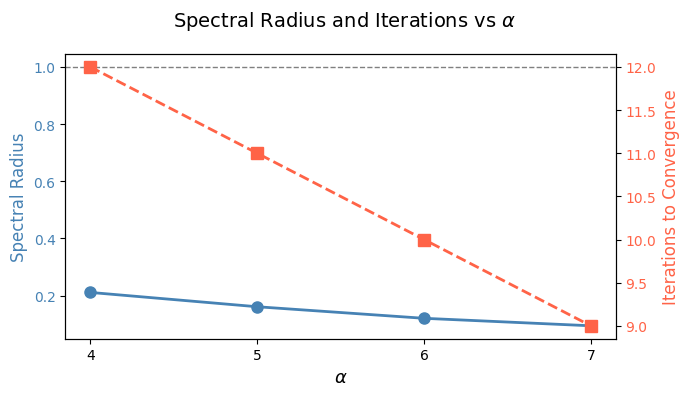

In [7]:
# Values of alpha to investigate
alphas = [4, 5, 6, 7]

spectral_radii = []
iterations_list = []

for alpha in alphas:
    # Build matrix A with the current alpha on the (4,4) diagonal entry
    A_q2 = np.array([
        [10.0, -1.0,  2.0,  0.0],
        [-1.0, 11.0, -1.0,  3.0],
        [ 2.0, -1.0, 10.0, -1.0],
        [ 0.0,  3.0, -1.0, float(alpha)]
    ])
    b_q2 = np.array([0.0, 1.0, 1.0, 0.0])

    # Compute spectral radius of the Gauss-Seidel iteration matrix
    rho = SpectralRadius(A_q2)
    spectral_radii.append(rho)

    # Run Gauss-Seidel and record iterations
    result = GaussSeidel(A_q2, b_q2, TOL=1e-8, N=30)
    if isinstance(result, tuple):
        _, k = result
    else:
        k = 30   # did not converge within N iterations
    iterations_list.append(k)

    print(f"alpha = {alpha}: spectral radius = {rho:.6f}, iterations = {k}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 4))

colour1 = "blue"
ax1.set_xlabel(r"$\alpha$", fontsize=13)
ax1.set_ylabel("Spectral Radius", color=colour1, fontsize=12)
ax1.plot(alphas, spectral_radii, "o-", color=colour1, linewidth=2, markersize=8, label="Spectral Radius")
ax1.tick_params(axis="y", labelcolor=colour1)
ax1.axhline(1, color="grey", linestyle="--", linewidth=1, label=r"$\rho = 1$")

ax2 = ax1.twinx()                      # Second y-axis for iteration count
colour2 = "orange"
ax2.set_ylabel("Iterations to Convergence", color=colour2, fontsize=12)
ax2.plot(alphas, iterations_list, "s--", color=colour2, linewidth=2, markersize=8, label="Iterations")
ax2.tick_params(axis="y", labelcolor=colour2)

ax1.set_xticks(alphas)
fig.suptitle(r"Spectral Radius and Iterations vs $\alpha$", fontsize=14)
plt.show()


(c) What do you observe? Explain whether the result makes sense or not.

As $\alpha$ increases from 4 to 7, the spectral radius $\rho(T)$ of the Gauss-Seidel iteration matrix decreases (0.211 → 0.095), and the number of iterations required for convergence decreases accordingly.

This makes sense: the Gauss-Seidel method is guaranteed to converge if and only if $\rho(T) < 1$. Moreover, the smaller the spectral radius, the faster the error is reduced at each iteration (roughly by a factor of $\rho$ per step), so fewer iterations are needed to satisfy the tolerance $10^{-8}$.

Increasing $\alpha$ makes the diagonal entry $a_{44}$ larger relative to the off-diagonal entries in that row, strengthening the diagonal dominance of $A$. Stronger diagonal dominance leads to a smaller spectral radius and therefore faster convergence.
